<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Inproving_CNN_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

In [2]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data() #carregamento base de dados

x_train, x_test = x_train / 255.0, x_test / 255.0 #normaliznado em 0 até 1
y_train, y_test = y_train.flatten(), y_test.flatten() #deixando em um vetor

print(x_train.shape,  y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 152s 1us/step
(50000, 32, 32, 3) (50000,)


In [3]:
K = len(set(y_train))
K

10

In [4]:
i = Input(shape=x_train[0].shape) # camada de entrada

x = Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(i)
x = BatchNormalization()(x)

x = Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x) # diminuir dimensão da imagem

x = Conv2D(64, (3, 3),  activation='relu', padding='same')(x) # segunda
x = BatchNormalization()(x) # normalizar os dados

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)#normalizar os dados
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3, 3),  activation='relu', padding='same')(x) # terceira
x = BatchNormalization()(x) # normalizar os dados

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # normalizar os dados
x = MaxPooling2D(2,2)(x) # diminuir dimensão da imagem

x = Flatten()(x)

x = Dropout(0.2)(x) # dropout para evitar overffiting
x = Dense(1024, activation='relu')(x) # camadad densa
x = Dropout(0.2)(x) # denovo, evitando overfitting

x = Dense(K, activation='softmax')(x) # camada de saída

model = Model(i, x)

In [5]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train,y_train, validation_data=(x_test, y_test), epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.4626 - loss: 1.4944 - val_accuracy: 0.4579 - val_loss: 1.4827
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5809 - loss: 1.1895 - val_accuracy: 0.5978 - val_loss: 1.1466
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6350 - loss: 1.0431 - val_accuracy: 0.6194 - val_loss: 1.0819
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6760 - loss: 0.9292 - val_accuracy: 0.6590 - val_loss: 0.9660
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7019 - loss: 0.8539 - val_accuracy: 0.6313 - val_loss: 1.1070


In [6]:
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1,
                                                           horizontal_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size
r = model.fit(train_generator, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.6433 - loss: 1.0201 - val_accuracy: 0.6680 - val_loss: 0.9615
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - accuracy: 0.6589 - loss: 0.9784 - val_accuracy: 0.6614 - val_loss: 0.9797
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.6773 - loss: 0.9361 - val_accuracy: 0.6806 - val_loss: 0.8996
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.6807 - loss: 0.9144 - val_accuracy: 0.6771 - val_loss: 0.9172
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.6922 - loss: 0.8870 - val_accuracy: 0.6975 - val_loss: 0.8875


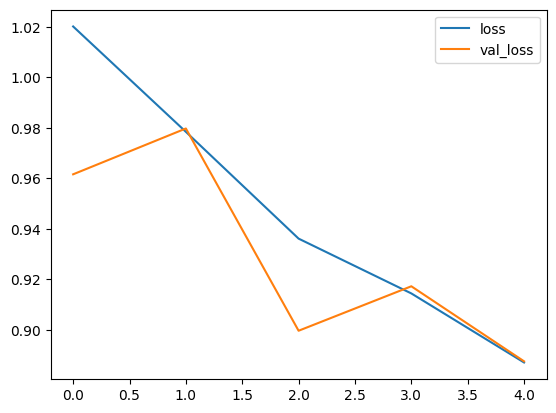

In [7]:
# taxas de erro por interação
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

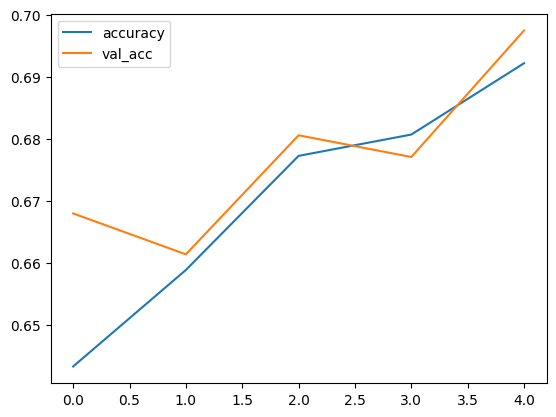

In [8]:
# taxas de erro e acurácia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Confusion matrix, without normalization
[[779  27   9  11  12   4   2  14  90  52]
 [ 14 831   0   7   1   1   7   3  42  94]
 [115  16 468  62 124  55  58  48  33  21]
 [ 40  22  37 507  59 129  80  47  35  44]
 [ 39   7  42  58 621  18  69  96  37  13]
 [ 24  12  33 196  47 498  42  92  30  26]
 [ 15  10  32  42  41  15 809   9  16  11]
 [ 22   6  10  33  36  45   9 797  10  32]
 [ 40  29   4   5   1   4   3   4 877  33]
 [ 28 118   4   8   0   6   5  11  32 788]]


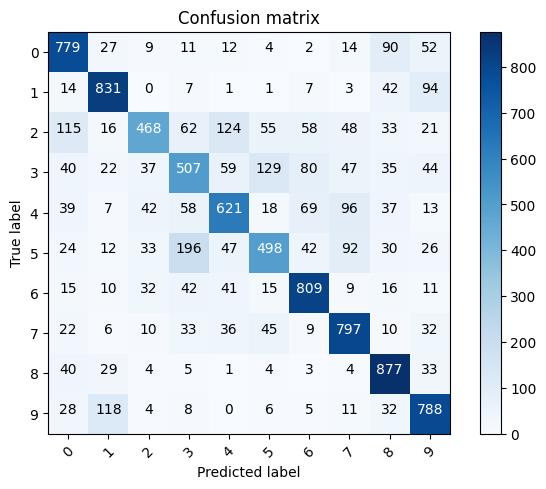

In [9]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plotagem da matriz
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x
    plt.yticks(tick_marks, classes) # rotulos do eixo y

    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto
    # adicionando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # adicionando rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# fazendo a predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [10]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,648 (4.93 MB)

 Trainable params: 430,250 (1.64 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 860,502 (3.28 MB)